# **Future Of Deep Learning**

**Laboratorium:** Techniki sieci Feed-Forward w PyTorch

**Zadanie**: Zbuduj klasyfikator zdolności kredytowej z użyciem zbioru Bank Marketing Dataset

**Dane:** Zbiór  służy do analizy i predykcji decyzji kredytowych (czy klient otrzyma loan: yes/no). Zawiera dane marketingowe uzyskane z banków, np. cechy klientów, wcześniejsze interakcje i informacje demograficzne, które mogą wpływać na decyzję o przyznaniu pożyczki

**Źródło:** https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset

## Definicje

###Funkcja aktywacji
Funkcja aktywacji to funkcja matematyczna stosowana w neuronach sieci neuronowej, która przekształca sumę ważoną wejść w wyjście neuronu. Wprowadza nieliniowość, dzięki czemu sieć może uczyć się złożonych zależności w danych, a nie tylko liniowych kombinacji wejść.

Najpopularniejsze funkcje aktywacji to:

* ReLU (Rectified Linear Unit) – szybka i skuteczna w głębokich sieciach, zwraca zero dla wartości ujemnych. ReLU stosuje się w ukrytych warstwach sieci neuronowej dla problemów z wieloma cechami wejściowymi, ponieważ przyspiesza uczenie i dobrze radzi sobie z głębokimi sieciami..
* Sigmoid – kompresuje wartości do przedziału 0–1, stosowana najczęscie w klasyfikacji binarnej w warstwie wyjściowej.
* Tanh – zwraca wartości w przedziale -1 do 1, centrowana wokół zera. Tanh stosuje się w ukrytych warstwach, gdy wartości wejściowe powinny być centrowane wokół zera, co może poprawić stabilność uczenia i rozkład gradientów
* Leaky ReLU – wariant ReLU, pozwala na niewielkie wartości dla ujemnych wejść, zapobiega „umieraniu neuronów”.
* Softmax – przekształca wektor wyjść w prawdopodobieństwa klas sumujące się do 1, używana w klasyfikacji wieloklasowej.

W PyTorch funkcje aktywacji stosuje się w definicji sieci (zwykle w konstruktorze klasy) oraz przez wyołania w implementacji abstrakcyjnej metody  `forward()`.

###Regularyzacja

Regularyzacja to technika ograniczająca złożoność modelu, aby zapobiec nadmiernemu dopasowaniu (overfittingowi) do danych treningowych.

Polega na wprowadzeniu dodatkowego składnika do funkcji straty, który karze model za zbyt duże wartości wag lub zbyt duże zróżnicowanie aktywacji.

* **L1** – kara proporcjonalna do sumy wartości bezwzględnych wag; Uwaga - może wyzerować część wag (nienadzorowana selekcja cech) z tego względu L1 stosujemy wyłącznie gdy chcemy uprościć model i wyzerować nieistotne cechy.
* **L2** - weight decay – dodaje karę proporcjonalną do sumy kwadratów wag. Domyślny wybór w sieciach neuronowych, stosujemy gdy chcemy ograniczyć duże wagi, co stabilizuje uczenie (z dużymi wagami model reaguje zbyt gwałtownie na małe zmiany danych).

W PyTorch L2 wprowadza się najczęściej w optymalizatorze poprzez parametr weight_decay.

###Dropout

Dropout polega na losowym wyłączaniu części neuronów w trakcie treningu sieci. Dzięki temu sieć nie uczy się polegać na konkretnych połączeniach między neuronami, lecz rozwija bardziej odporne i ogólne reprezentacje danych. W praktyce dropout symuluje działanie wielu różnych sieci o wspólnych wagach, co poprawia zdolność generalizacji.

W PyTorch dropout stosuje się w definicji sieci (zwykle w konstruktorze klasy) oraz przez wyołania w implementacji abstrakcyjnej metody `forward()`.

### Learning rate

Learning rate (współczynnik uczenia) określa, jak duże kroki robią wagi sieci podczas optymalizacji w kierunku minimalizacji funkcji straty.

Jeśli learning rate jest zbyt duży, wagi mogą „przeskakiwać” przez minimum funkcji straty, co prowadzi do niestabilnego uczenia i słabych wyników. Jeśli jest zbyt mały, uczenie przebiega bardzo wolno i może utkwić w lokalnych minimach. Dobór odpowiedniego learning rate pozwala modelowi szybko i stabilnie zbliżać się do optymalnych wag, zachowując równowagę między szybkością uczenia a dokładnością predykcji. W PyTorch learning rate definiuje się przy inicjowaniu optymalizatora.

### Metryki

* Dokładność (accuracy) to odsetek poprawnie sklasyfikowanych próbek w zbiorze testowym lub walidacyjnym.

* Precision (precyzja) – odsetek próbek, które model oznaczył jako pozytywne, a które faktycznie są pozytywne. Mówi o tym, jak bardzo możemy ufać pozytywnym predykcjom modelu, np. spośród 25 przewidzianych jako chorzy, 15 faktycznie jest chorych, więc precyzja = 15/25 = 0,6 (60%). To mówi, że jeśli model stwierdzi chorobę, w 60% przypadków jest to prawda.

* Recall (sensitivity, czułość) – odsetek wszystkich prawdziwych próbek pozytywnych, które model poprawnie wykrył jako pozytywne, spośród 20 prawdziwych przypadków choroby, model wykrył 15, więc recall = 15/20 = 0,75 (75%). To pokazuje, że model znalazł 75% wszystkich chorych pacjentów.

Różnica Precision/Recall: precision patrzy z perspektywy przewidywań modelu, mierzy poprawność predykcji modelu. Z kolei recall mierzy zdolność modelu do wykrycia wszystkich rzeczywistych przypadków pozytywnych.

* F1-score to średnia harmoniczna między precyzją (precision) a czułością (recall), używana w klasyfikacji, gdy klasy są niezbalansowane, aby ocenić ogólną skuteczność modelu.

W PyTorch metryki zwykle oblicza się je na tensorach po konwersji na NumPy np. `cpu().numpy()`i korzystamy z funkcji ze scikit-learn (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`) do obliczenia metryk.

# - Baza (dataset + device + przgotowywanie danych do uczenia)

In [ ]:
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

import kagglehub
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Pobranie zestawu danych z Kaggle przez kagglehub
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

# Lista wszystkich plików CSV w pobranym katalogu
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Pełna ścieżka do pierwszego pliku CSV
csv_path = os.path.join(path, csv_files[0])

# Wczytanie danych do DataFrame
df = pd.read_csv(csv_path, sep=',')

# Rozdzielenie cech (X) od etykiety docelowej (y)
X = df.drop('loan', axis=1) #nasze zmienne objaśniające / predyktory
# Mapowanie wartości 'yes' -> 1 i 'no' -> 0 dla kolumny docelowej
y = df['loan'].map({'yes': 1, 'no': 0}) #nasza zmienna zależna / target

# Wybór kolumn kategorycznych i numerycznych
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Mapowanie nazw miesięcy na liczby
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# Mapowanie poziomu wykształcenia na liczby
education_map = {
    'primary': 1, 'secondary': 2, 'tertiary': 3, 'unknown': 0
}

# Tworzymy kopię danych kategorycznych
X_cat_encoded = X[categorical_cols].copy()

# Kodowanie kolumn kategorycznych
for col in categorical_cols:
    if col == 'month':
        # Mapowanie miesięcy na liczby
        X_cat_encoded[col] = X_cat_encoded[col].map(month_map)
    elif col == 'education':
        # Mapowanie wykształcenia na liczby
        X_cat_encoded[col] = X_cat_encoded[col].map(education_map)
    else:
        # Dla pozostałych kolumn kategorycznych użycie LabelEncoder (każda unikalna wartość kategorii dostaje unikalną liczbę całkowitą.)
        le = LabelEncoder()
        X_cat_encoded[col] = le.fit_transform(X_cat_encoded[col].astype(str))

# Standaryzacja kolumn numerycznych - standaryzujemy, żeby wszystkie cechy numeryczne miały podobną skalę (średnia = 0, odchylenie standardowe = 1).
# To zapobiega dominacji cech o dużych wartościach i przyspiesza oraz stabilizuje uczenie
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X[numeric_cols]),  # skalowanie wartości
    columns=numeric_cols,                   # zachowanie nazw kolumn
    index=X.index                            # zachowanie indeksów
)

# Łączenie kolumn numerycznych i zakodowanych kategorycznych
X_prepared = pd.concat([X_num_scaled, X_cat_encoded], axis=1)

# Podział danych na zbiór treningowy i testowy (70%/30%) z zachowaniem proporcji klas
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.3, random_state=42, stratify=y
)

# Wyświetlenie rozmiarów zbiorów
print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 1 - przygotowane dane zmieniamy na Tensory, bo będziemy używać Pytorcha
X_train_tensor = torch.FloatTensor(X_train.values)
X_test_tensor = torch.FloatTensor(X_test.values)
y_train_tensor = torch.LongTensor(y_train.values)
y_test_tensor = torch.LongTensor(y_test.values)

# 2 - TensorDataset łączy cechy X i etykiety y w spójny zbiór danych, gdzie każda etykieta jest dopasowana do swoich cech
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 3 - DataLoader dzieli dane na batch’e, co przyspiesza trening i stabilizuje uczenie.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# shuffle=True/False - na treningu mieszamy dane, test nie! tam kolejność nie ma dla nas znaczenia
# w treningu model moze się nauczyć nie wzorców a koeljności


100%|██████████| 142k/142k [00:00<00:00, 452kB/s]

Extracting files...
Rozmiar zbioru treningowego: (7813, 16)
Rozmiar zbioru testowego: (3349, 16)
Device: cpu


# 1. SIMPLE FFNN

In [ ]:
class SimpleFFNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # warstwa ukryta
        self.relu = nn.ReLU()                         # funkcja aktywacji
        self.fc2 = nn.Linear(hidden_size, output_size) # warstwa wyjściowa

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Parametry - można wpisać bezpośrednio w model
input_size = X_train.shape[1]  # 16 cech
hidden_size = 16 # tym możemy sobie sterować
output_size = len(np.unique(y_train))  # liczba klas = 2 (tak/nie)

model = SimpleFFNN(input_size, hidden_size, output_size).to(device)

# Definiuje funkcję straty dla klasyfikacji wieloklasowej
criterion = nn.CrossEntropyLoss()
# Tworzy optymalizator Adam z wartością learning rate. Adam przydziela każdej wadze własny współczynnik uczenia:
# - Wagi z dużymi gradientami dostają mniejszy krok, aby nie „przeskoczyć” minimum.
# - Wagi z małymi gradientami dostają większy krok, aby szybciej się uczyć.
optimizer = optim.Adam(model.parameters(), lr=0.01)

# --- Parametry treningu ---
num_epochs = 30

# listy do zapisywania strat i dokładności dla wykresów
train_losses, train_accs = [], []
val_losses, val_accs = [], []

# --- Pętla treningowa ---
for epoch in range(num_epochs):
    # --- tryb treningowy ---
    model.train() # ustawia model w tryb treningowy; aktywuje Dropout i BatchNorm.
    total_loss = 0
    correct_train, total_train = 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)  # przesyłamy dane na GPU/CPU
        optimizer.zero_grad()                   # zerowanie gradientów
        outputs = model(xb)                     # forward pass
        loss = criterion(outputs, yb)           # obliczenie straty
        loss.backward()                         # backward pass
        optimizer.step()                        # aktualizacja wag

        total_loss += loss.item() * xb.size(0)  # sumowanie strat
        preds = torch.argmax(outputs, dim=1) # preds = indeksy klas z najwyższym prawdopodobieństwem w outputach modelu
        correct_train += (preds == yb).sum().item() # zliczamy liczbę poprawnych predykcji w bieżącej partii
        total_train += yb.size(0) # zliczamy całkowitą liczbę próbek w bieżącej partii

    train_loss = total_loss / total_train # obliczamy stratę
    train_acc = correct_train / total_train # i uzyskaną dokładność

    # --- tryb ewaluacji ---
    model.eval() # ustawia model w tryb ewaluacji; dezaktywuje Dropout i ustala BatchNorm w trybie inferencji (uśrednianie zamiast aktualizacji).
    val_loss_total = 0
    correct_val, total_val = 0, 0

    with torch.no_grad():  # wyłączamy gradienty
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_loss_total += loss.item() * xb.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == yb).sum().item()
            total_val += yb.size(0)

    val_loss = val_loss_total / total_val
    val_acc = correct_val / total_val

    # zapis do list do wykresów
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # raportowanie wyników w każdej epoce
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/30 | Train Loss: 0.3917, Train Acc: 0.8632 | Val Loss: 0.3699, Val Acc: 0.8692
Epoch 2/30 | Train Loss: 0.3728, Train Acc: 0.8694 | Val Loss: 0.3667, Val Acc: 0.8692
Epoch 3/30 | Train Loss: 0.3704, Train Acc: 0.8692 | Val Loss: 0.3677, Val Acc: 0.8683
Epoch 4/30 | Train Loss: 0.3689, Train Acc: 0.8702 | Val Loss: 0.3668, Val Acc: 0.8692
Epoch 5/30 | Train Loss: 0.3688, Train Acc: 0.8700 | Val Loss: 0.3694, Val Acc: 0.8677
Epoch 6/30 | Train Loss: 0.3644, Train Acc: 0.8701 | Val Loss: 0.3683, Val Acc: 0.8680
Epoch 7/30 | Train Loss: 0.3648, Train Acc: 0.8689 | Val Loss: 0.3706, Val Acc: 0.8644
Epoch 8/30 | Train Loss: 0.3616, Train Acc: 0.8702 | Val Loss: 0.3699, Val Acc: 0.8683
Epoch 9/30 | Train Loss: 0.3633, Train Acc: 0.8688 | Val Loss: 0.3771, Val Acc: 0.8632
Epoch 10/30 | Train Loss: 0.3628, Train Acc: 0.8691 | Val Loss: 0.3709, Val Acc: 0.8653
Epoch 11/30 | Train Loss: 0.3595, Train Acc: 0.8707 | Val Loss: 0.3820, Val Acc: 0.8689
Epoch 12/30 | Train Loss: 0.3612, Train A

# 2. DEEP FFNN (Bazowy, bez modyfikacji)

In [ ]:
class DeepFFNN(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        super(DeepFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1_size, hidden2_size) # dodatkowa warstwa
        self.relu2 = nn.ReLU()                           # dodatkowa funkcja aktywacji
        self.fc3 = nn.Linear(hidden2_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

input_size = X_train.shape[1]  # 16 cech
hidden1_size = 32
hidden2_size = 16
output_size = len(np.unique(y_train))  # liczba klas = 2 (tak/nie)

model_deepffnn = DeepFFNN(input_size, hidden1_size, hidden2_size, output_size).to(device)

# 3. Funcja do Deep FFNN (Podstawow/Bazowa, bez modyfikacji)

In [ ]:
def train_and_evaluate(model,
                       train_loader,
                       test_loader,
                       num_epochs=30,
                       learning_rate=0.01,
                       weight_decay=0.0,
                       device='cpu',
                       verbose=True,
                       plot=True):
    """
    Trenuje model, zwraca wyniki i rysuje wykresy strat oraz dokładności.

    Args:
        model: instancja nn.Module
        train_loader: DataLoader dla zbioru treningowego
        test_loader: DataLoader dla zbioru testowego (walidacyjnego)
        num_epochs: liczba epok
        learning_rate: współczynnik uczenia
        weight_decay: L2 regularization
        device: 'cpu' lub 'cuda'
        verbose: czy wypisywać postęp
        plot: czy wyświetlić wykresy

    Returns:
        dict z wynikami: train_losses, val_losses, train_accs, val_accs, model
    """

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(num_epochs):
        # Trening
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)

        train_loss = total_loss / total_train
        train_acc = correct_train / total_train

        # Walidacja
        model.eval()
        val_loss_total = 0
        correct_val, total_val = 0, 0

        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss_total += loss.item() * xb.size(0)

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == yb).sum().item()
                total_val += yb.size(0)

        val_loss = val_loss_total / total_val
        val_acc = correct_val / total_val

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Wykresy
    if plot:
        epochs_range = range(1, num_epochs + 1)
        plt.figure(figsize=(12, 5))

        # Wykres strat
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, train_losses, label='Train Loss')
        plt.plot(epochs_range, val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss over Epochs')
        plt.legend()
        plt.grid(True)

        # Wykres dokładności
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_accs, label='Train Accuracy')
        plt.plot(epochs_range, val_accs, label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy over Epochs')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return {
        'model': model,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs
    }

#Zadania

## 4. Modyfikacja architektury

1. Dodaj warstwy ukryte i eksperymentuj z różna liczbą neuornów.
2. Porównaj krzywe strat i dokładności z wersją podstawową.
3. **Odpowiedz**: czy zwiększenie liczby neuronów poprawiło dokładność walidacyjną? Czy czas treningu wzrósł?

In [ ]:
class DeeperFFNN(nn.Module):
    def __init__(self, input_size, h1, h2, h3, output_size):
        super(DeeperFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, h1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(h1, h2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(h2, h3) # + warstawa ukryta
        self.relu3 = nn.ReLU()       # + warstwa aktywacji
        self.fc4 = nn.Linear(h3, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

class WiderFFNN(nn.Module):
    def __init__(self, input_size, h1, h2, output_size):
        super(WiderFFNN, self).__init__()
        self.fc1 = nn.Linear(input_size, h1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(h1, h2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(h2, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

--- Trenowanie modelu podstawowego (32 -> 16) ---
Epoch 1/30 | Train Loss: 0.3827, Train Acc: 0.8692 | Val Loss: 0.3711, Val Acc: 0.8692
Epoch 2/30 | Train Loss: 0.3712, Train Acc: 0.8692 | Val Loss: 0.3696, Val Acc: 0.8692
Epoch 3/30 | Train Loss: 0.3701, Train Acc: 0.8689 | Val Loss: 0.3740, Val Acc: 0.8692
Epoch 4/30 | Train Loss: 0.3663, Train Acc: 0.8691 | Val Loss: 0.3706, Val Acc: 0.8692
Epoch 5/30 | Train Loss: 0.3646, Train Acc: 0.8688 | Val Loss: 0.3718, Val Acc: 0.8692
Epoch 6/30 | Train Loss: 0.3634, Train Acc: 0.8692 | Val Loss: 0.3693, Val Acc: 0.8692
Epoch 7/30 | Train Loss: 0.3616, Train Acc: 0.8692 | Val Loss: 0.3685, Val Acc: 0.8692
Epoch 8/30 | Train Loss: 0.3614, Train Acc: 0.8693 | Val Loss: 0.3693, Val Acc: 0.8677
Epoch 9/30 | Train Loss: 0.3595, Train Acc: 0.8689 | Val Loss: 0.3856, Val Acc: 0.8617
Epoch 10/30 | Train Loss: 0.3606, Train Acc: 0.8687 | Val Loss: 0.3660, Val Acc: 0.8683
Epoch 11/30 | Train Loss: 0.3589, Train Acc: 0.8705 | Val Loss: 0.3685, Val Acc

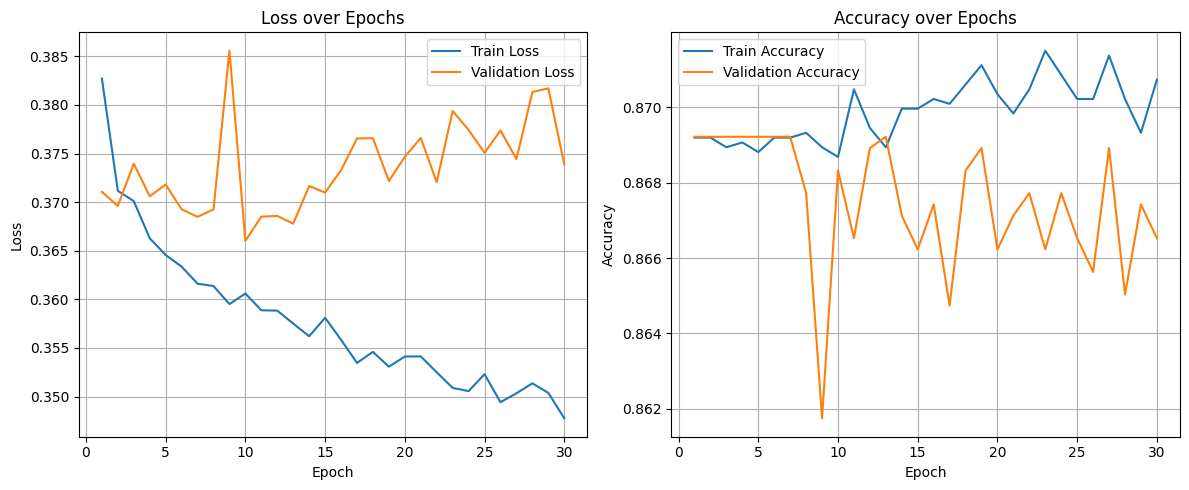

Czas trenowania modelu BAZOWEGO: 14.95 sekund

-- Trenowanie modelu GŁĘBSZEGO (32 -> 16 -> 8)
Epoch 1/30 | Train Loss: 0.3886, Train Acc: 0.8659 | Val Loss: 0.3695, Val Acc: 0.8692
Epoch 2/30 | Train Loss: 0.3761, Train Acc: 0.8692 | Val Loss: 0.3738, Val Acc: 0.8692
Epoch 3/30 | Train Loss: 0.3707, Train Acc: 0.8692 | Val Loss: 0.3703, Val Acc: 0.8692
Epoch 4/30 | Train Loss: 0.3667, Train Acc: 0.8692 | Val Loss: 0.3679, Val Acc: 0.8692
Epoch 5/30 | Train Loss: 0.3662, Train Acc: 0.8692 | Val Loss: 0.3687, Val Acc: 0.8692
Epoch 6/30 | Train Loss: 0.3648, Train Acc: 0.8692 | Val Loss: 0.3751, Val Acc: 0.8692
Epoch 7/30 | Train Loss: 0.3649, Train Acc: 0.8692 | Val Loss: 0.3663, Val Acc: 0.8692
Epoch 8/30 | Train Loss: 0.3637, Train Acc: 0.8689 | Val Loss: 0.3683, Val Acc: 0.8692
Epoch 9/30 | Train Loss: 0.3639, Train Acc: 0.8689 | Val Loss: 0.3724, Val Acc: 0.8692
Epoch 10/30 | Train Loss: 0.3620, Train Acc: 0.8692 | Val Loss: 0.3718, Val Acc: 0.8692
Epoch 11/30 | Train Loss: 0.3632, T

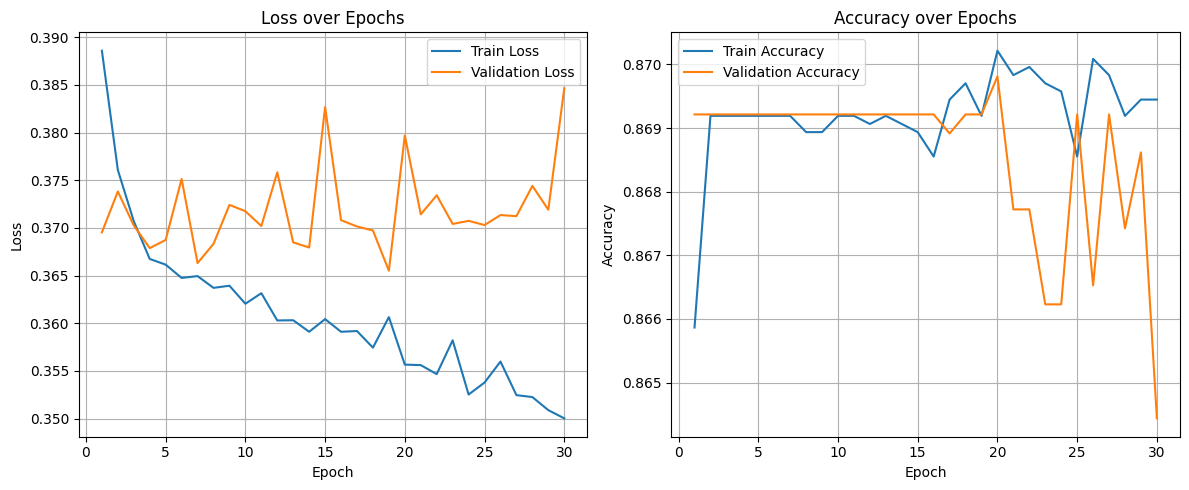

Czas trenowania modelu GŁĘBSZEGO: 19.05 sekund

-- Trenowanie modelu SZERSZEGO (64->32) 
Epoch 1/30 | Train Loss: 0.3851, Train Acc: 0.8674 | Val Loss: 0.3716, Val Acc: 0.8692
Epoch 2/30 | Train Loss: 0.3743, Train Acc: 0.8689 | Val Loss: 0.3866, Val Acc: 0.8692
Epoch 3/30 | Train Loss: 0.3719, Train Acc: 0.8691 | Val Loss: 0.3930, Val Acc: 0.8692
Epoch 4/30 | Train Loss: 0.3691, Train Acc: 0.8691 | Val Loss: 0.3706, Val Acc: 0.8692
Epoch 5/30 | Train Loss: 0.3659, Train Acc: 0.8700 | Val Loss: 0.3694, Val Acc: 0.8677
Epoch 6/30 | Train Loss: 0.3651, Train Acc: 0.8698 | Val Loss: 0.3666, Val Acc: 0.8692
Epoch 7/30 | Train Loss: 0.3632, Train Acc: 0.8697 | Val Loss: 0.3726, Val Acc: 0.8686
Epoch 8/30 | Train Loss: 0.3618, Train Acc: 0.8700 | Val Loss: 0.3680, Val Acc: 0.8689
Epoch 9/30 | Train Loss: 0.3634, Train Acc: 0.8694 | Val Loss: 0.3738, Val Acc: 0.8662
Epoch 10/30 | Train Loss: 0.3635, Train Acc: 0.8700 | Val Loss: 0.3678, Val Acc: 0.8692
Epoch 11/30 | Train Loss: 0.3594, Train 

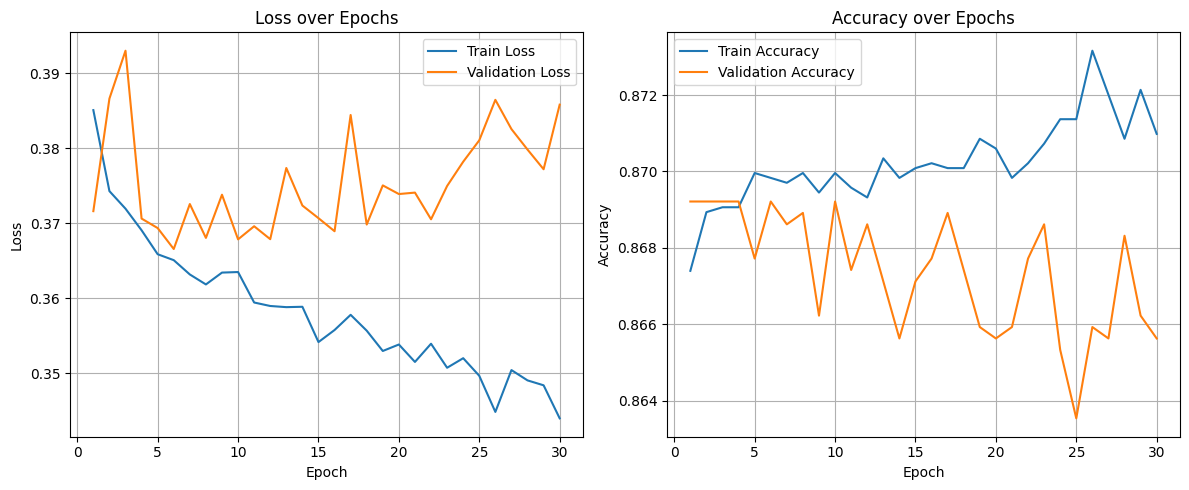

Czas trenowania modelu szerszego modelu: 15.33 sekund


In [ ]:
import time

# 1. Trening modelu Podstawowego
model_base = DeepFFNN(input_size, 32, 16, output_size).to(device)
print("--- Trenowanie modelu podstawowego (32 -> 16) ---")

start_time_base = time.time()
train_and_evaluate(model_base, train_loader, test_loader, num_epochs=30, device=device)
end_time_base = time.time()

duration_base = end_time_base-start_time_base
print(f"Czas trenowania modelu BAZOWEGO: {duration_base:.2f} sekund")


# 2. Trening modelu GŁĘBSZEGO (32 -> 16 -> 8)
model_deeper = DeeperFFNN(input_size, 32, 16, 8, output_size).to(device)
print("\n-- Trenowanie modelu GŁĘBSZEGO (32 -> 16 -> 8)")

start_time_deeper = time.time()
train_and_evaluate(model_deeper, train_loader, test_loader, num_epochs=30, device=device)
end_time_deeper = time.time()

duration_deeper = end_time_deeper-start_time_deeper
print(f"Czas trenowania modelu GŁĘBSZEGO: {duration_deeper:.2f} sekund")


# 3. Trening modelu SZERSZEGO (64 -> 32)
model_wider = WiderFFNN(input_size, 64, 32, output_size).to(device)
print("\n-- Trenowanie modelu SZERSZEGO (64->32) ")

start_time_wider = time.time()
train_and_evaluate(model_wider, train_loader, test_loader, num_epochs=30, device=device)
end_time_wider = time.time()

duration_wider = end_time_wider-start_time_wider
print(f"Czas trenowania modelu szerszego modelu: {duration_wider:.2f} sekund")

**ODPOWIEDŻ**

1. Analiza wykazała, że skomplikowanie architektury (więcej warstw lub neuronów) nie poprawiło dokładności walidacyjnej
2. Większe modele trenowały się szybciej (15-17 sekund) w porównaniu do bazowego (19 sekund) [dziwne]


## 5. Eksperymenty z różnymi funkcjami aktywacji.

* Zmieniaj funkcje aktywacji w warstwach ukrytych: ReLU, LeakyReLU, ELU, Tanh.
* Naucz model dla każdej z funkcji i porównaj:
  * krzywe strat i dokładności treningowej i walidacyjnej
  * końcową dokładność, F1-score, recall (sensitivity) dla klasy 1 (choroba serca).
* **Odpowiedz**: która funkcja aktywacji zapewnia najlepszą konwergencję i dlaczego ? Uzasadnij swoje obserwacje.

### Zmodyfikowana funkcja train_and_evaluate, żeby też zwracała potrzebne metryki:

In [ ]:
def train_and_evaluate_metrics(model,
                               train_loader,
                               test_loader,
                               num_epochs=30,
                               learning_rate=0.01,
                               weight_decay=0.0,
                               device='cpu',
                               verbose=True,
                               plot=True):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    val_f1s, val_recalls = [], []

    for epoch in range(num_epochs):
        # Trening
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == yb).sum().item()
            total_train += yb.size(0)

        train_loss = total_loss / total_train
        train_acc = correct_train / total_train

        # Walidacja
        model.eval()
        val_loss_total, total_val = 0, 0

        all_val_preds = []
        all_val_labels = []

        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_loss_total += loss.item() * xb.size(0)

                preds = torch.argmax(outputs, dim=1)
                total_val += yb.size(0)

                all_val_preds.append(preds.cpu())
                all_val_labels.append(yb.cpu())

        all_val_preds = torch.cat(all_val_preds).numpy()
        all_val_labels = torch.cat(all_val_labels).numpy()

        val_loss = val_loss_total / total_val
        val_acc = accuracy_score(all_val_labels, all_val_preds)
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
        val_recall = recall_score(all_val_labels, all_val_preds, average='macro')

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_f1s.append(val_f1)
        val_recalls.append(val_recall)

        if verbose:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
                  f"Val F1: {val_f1:.4f}, Val Recall: {val_recall:.4f}")

    # Wykresy
    if plot:
        epochs_range = range(1, num_epochs + 1)
        plt.figure(figsize=(12, 5))

        # Wykres strat
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, train_losses, label='Train Loss')
        plt.plot(epochs_range, val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss over Epochs')
        plt.legend()
        plt.grid(True)

        # Wykres dokładności
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_accs, label='Train Accuracy')
        plt.plot(epochs_range, val_accs, label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy over Epochs')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return {
        'model': model,
        'train_losses': train_losses, 'train_accs': train_accs,
        'val_losses': val_losses, 'val_accs': val_accs,
        'val_f1s': val_f1s, 'val_recalls': val_recalls
    }

In [ ]:
class FFNN_Activations(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size, activation_fn):
        super(FFNN_Activations, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, output_size)
        self.activation = activation_fn

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation_fn(x)
        x = self.fc2(x)
        x = self.activation_fn(x)
        x = self.fc3(x)
        return x

	 ReLU
Epoch 1/30 | Train Loss: 0.3848, Train Acc: 0.8692 | Val Loss: 0.3695, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 2/30 | Train Loss: 0.3732, Train Acc: 0.8692 | Val Loss: 0.3682, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 3/30 | Train Loss: 0.3710, Train Acc: 0.8691 | Val Loss: 0.3683, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 4/30 | Train Loss: 0.3692, Train Acc: 0.8692 | Val Loss: 0.3741, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 5/30 | Train Loss: 0.3654, Train Acc: 0.8692 | Val Loss: 0.3684, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 6/30 | Train Loss: 0.3635, Train Acc: 0.8692 | Val Loss: 0.3651, Val Acc: 0.8695, Val F1: 0.4674, Val Recall: 0.5011
Epoch 7/30 | Train Loss: 0.3624, Train Acc: 0.8697 | Val Loss: 0.3769, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 8/30 | Train Loss: 0.3626, Train Acc: 0.8692 | Val Loss: 0.3683, Val Acc: 0.8692, Val F1: 0.4695, Val Recall: 0.5019
Epoch 9/3

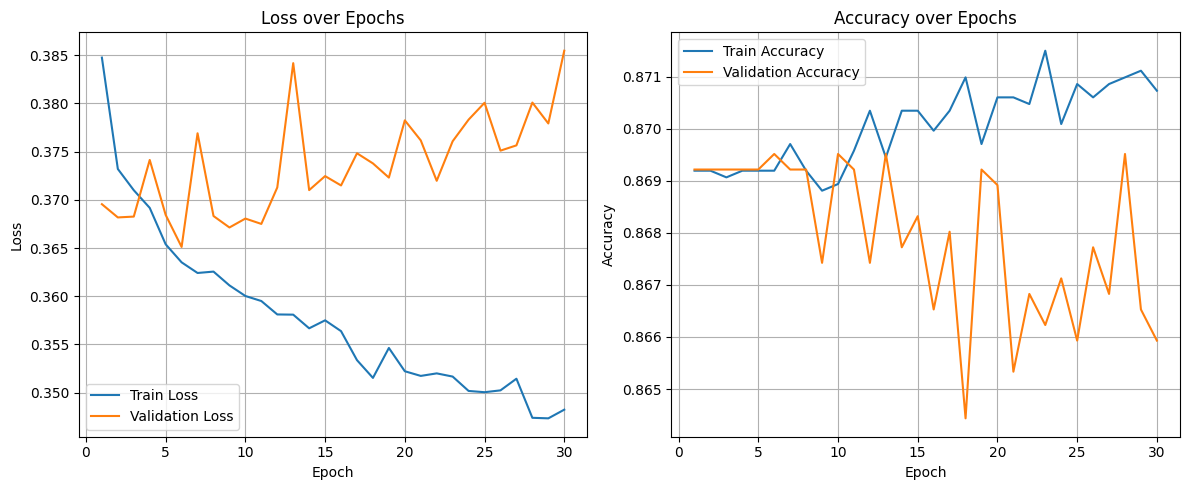


	 LeakyReLU
Epoch 1/30 | Train Loss: 0.3882, Train Acc: 0.8671 | Val Loss: 0.3698, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 2/30 | Train Loss: 0.3760, Train Acc: 0.8692 | Val Loss: 0.3759, Val Acc: 0.8674, Val F1: 0.4689, Val Recall: 0.5009
Epoch 3/30 | Train Loss: 0.3717, Train Acc: 0.8692 | Val Loss: 0.3706, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 4/30 | Train Loss: 0.3710, Train Acc: 0.8693 | Val Loss: 0.3687, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 5/30 | Train Loss: 0.3713, Train Acc: 0.8691 | Val Loss: 0.3694, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 6/30 | Train Loss: 0.3671, Train Acc: 0.8693 | Val Loss: 0.3729, Val Acc: 0.8647, Val F1: 0.4724, Val Recall: 0.5013
Epoch 7/30 | Train Loss: 0.3663, Train Acc: 0.8693 | Val Loss: 0.3685, Val Acc: 0.8695, Val F1: 0.4696, Val Recall: 0.5021
Epoch 8/30 | Train Loss: 0.3656, Train Acc: 0.8701 | Val Loss: 0.3685, Val Acc: 0.8683, Val F1: 0.4692, Val Recall: 0.5014
Epo

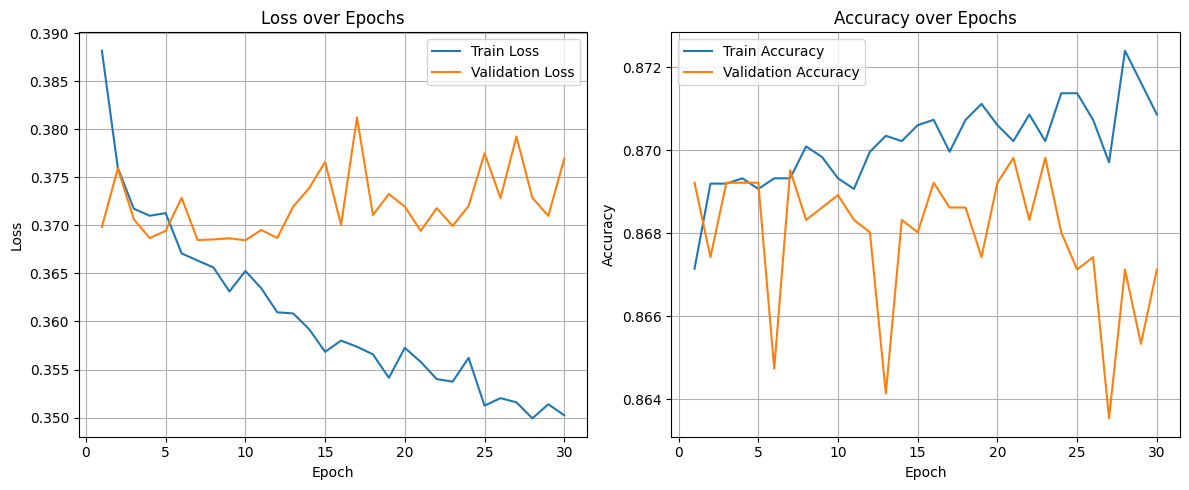


	 ELU
Epoch 1/30 | Train Loss: 0.3877, Train Acc: 0.8650 | Val Loss: 0.3725, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 2/30 | Train Loss: 0.3747, Train Acc: 0.8686 | Val Loss: 0.3693, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 3/30 | Train Loss: 0.3740, Train Acc: 0.8688 | Val Loss: 0.3770, Val Acc: 0.8680, Val F1: 0.4691, Val Recall: 0.5013
Epoch 4/30 | Train Loss: 0.3688, Train Acc: 0.8696 | Val Loss: 0.3812, Val Acc: 0.8677, Val F1: 0.4734, Val Recall: 0.5030
Epoch 5/30 | Train Loss: 0.3668, Train Acc: 0.8693 | Val Loss: 0.3687, Val Acc: 0.8695, Val F1: 0.4696, Val Recall: 0.5021
Epoch 6/30 | Train Loss: 0.3681, Train Acc: 0.8689 | Val Loss: 0.3706, Val Acc: 0.8692, Val F1: 0.4695, Val Recall: 0.5019
Epoch 7/30 | Train Loss: 0.3644, Train Acc: 0.8696 | Val Loss: 0.3769, Val Acc: 0.8677, Val F1: 0.4712, Val Recall: 0.5021
Epoch 8/30 | Train Loss: 0.3653, Train Acc: 0.8701 | Val Loss: 0.3747, Val Acc: 0.8638, Val F1: 0.4864, Val Recall: 0.5076
Epoch 9/3

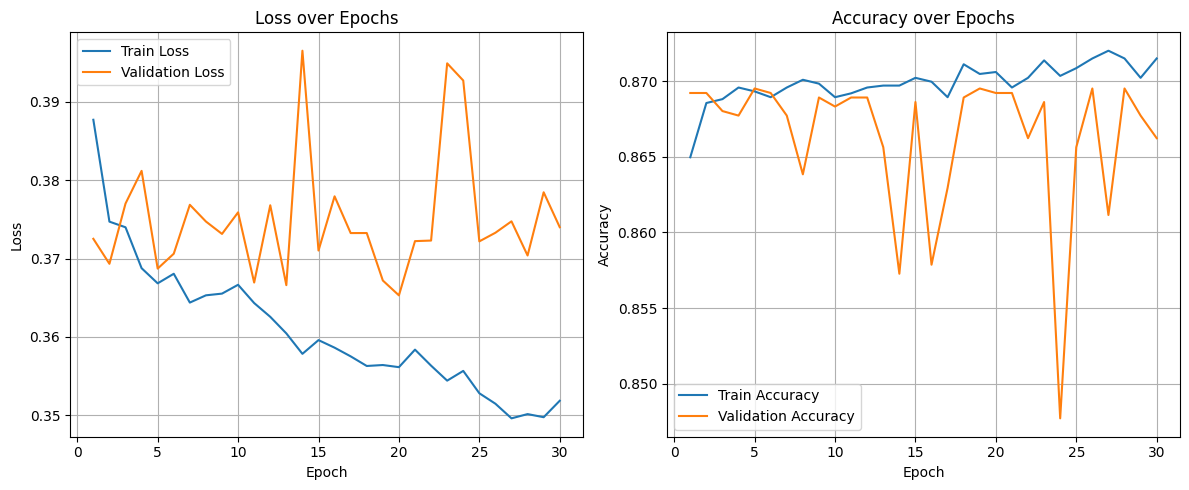


	 Tanh
Epoch 1/30 | Train Loss: 0.3893, Train Acc: 0.8674 | Val Loss: 0.3721, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 2/30 | Train Loss: 0.3774, Train Acc: 0.8693 | Val Loss: 0.3697, Val Acc: 0.8692, Val F1: 0.4650, Val Recall: 0.5000
Epoch 3/30 | Train Loss: 0.3712, Train Acc: 0.8687 | Val Loss: 0.3809, Val Acc: 0.8686, Val F1: 0.4671, Val Recall: 0.5006
Epoch 4/30 | Train Loss: 0.3748, Train Acc: 0.8686 | Val Loss: 0.3822, Val Acc: 0.8692, Val F1: 0.4673, Val Recall: 0.5010
Epoch 5/30 | Train Loss: 0.3715, Train Acc: 0.8671 | Val Loss: 0.3909, Val Acc: 0.8641, Val F1: 0.4722, Val Recall: 0.5010
Epoch 6/30 | Train Loss: 0.3675, Train Acc: 0.8694 | Val Loss: 0.3715, Val Acc: 0.8689, Val F1: 0.4672, Val Recall: 0.5008
Epoch 7/30 | Train Loss: 0.3656, Train Acc: 0.8698 | Val Loss: 0.3775, Val Acc: 0.8662, Val F1: 0.4686, Val Recall: 0.5002
Epoch 8/30 | Train Loss: 0.3627, Train Acc: 0.8689 | Val Loss: 0.3723, Val Acc: 0.8686, Val F1: 0.4802, Val Recall: 0.5064
Epoch 9/

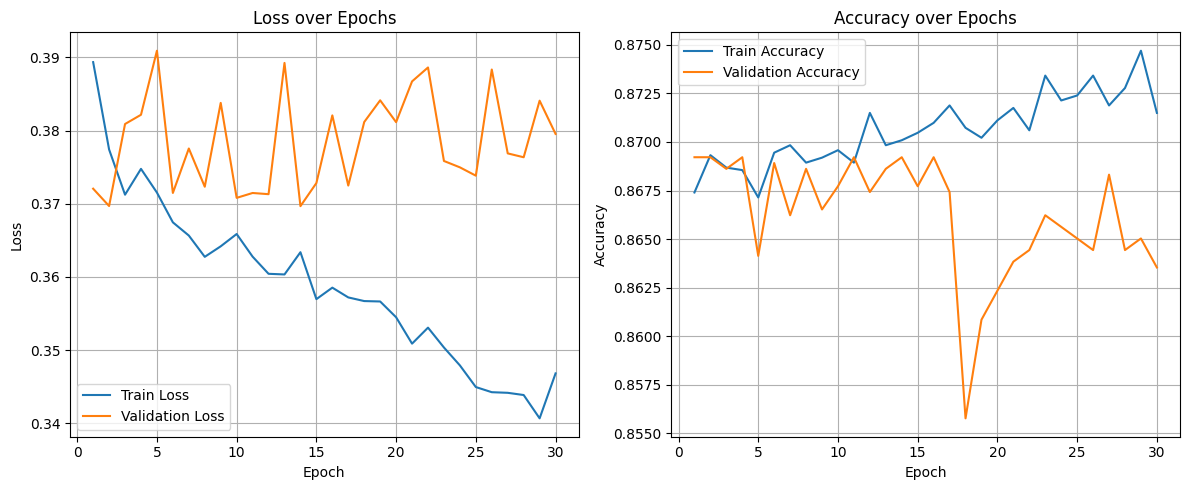


	 RESULTS OF EACH MODEL ON 30-rd EPOCH
ReLU: 		 Val Acc: 0.8659, Val F1: 0.4913, Val Recall: 0.5107
LeakyReLU: 	 Val Acc: 0.8671, Val F1: 0.4899, Val Recall: 0.5104
ELU: 		 Val Acc: 0.8662, Val F1: 0.4854, Val Recall: 0.5080
Tanh: 		 Val Acc: 0.8635, Val F1: 0.4802, Val Recall: 0.5045


In [ ]:
hidden1_size = 32
hidden2_size = 16
num_epochs = 30

# ReLu
print("\t ReLU")
model_relu = FFNN_Activations(input_size, hidden1_size, hidden2_size, output_size, nn.ReLU()).to(device)
results_relu = train_and_evaluate_metrics(model_relu, train_loader, test_loader, num_epochs=num_epochs, device=device)

# LeakyReLU [
print("\n\t LeakyReLU")
model_leaky_relu = FFNN_Activations(input_size, hidden1_size, hidden2_size, output_size, nn.LeakyReLU()).to(device)
results_leaky = train_and_evaluate_metrics(model_leaky_relu, train_loader, test_loader, num_epochs=num_epochs, device=device)

# ELU
print("\n\t ELU")
model_elu = FFNN_Activations(input_size, hidden1_size, hidden2_size, output_size, nn.ELU()).to(device)
results_elu = train_and_evaluate_metrics(model_elu, train_loader, test_loader, num_epochs=num_epochs, device=device)

# Tanh
print("\n\t Tanh")
model_tanh = FFNN_Activations(input_size, hidden1_size, hidden2_size, output_size, nn.Tanh()).to(device)
results_tanh = train_and_evaluate_metrics(model_tanh, train_loader, test_loader, num_epochs=num_epochs, device=device)

# RES
print("\n\t RESULTS OF EACH MODEL ON 30-rd EPOCH")
print(f"ReLU: \t\t Val Acc: {results_relu['val_accs'][-1]:.4f}, Val F1: {results_relu['val_f1s'][-1]:.4f}, Val Recall: {results_relu['val_recalls'][-1]:.4f}")
print(f"LeakyReLU: \t Val Acc: {results_leaky['val_accs'][-1]:.4f}, Val F1: {results_leaky['val_f1s'][-1]:.4f}, Val Recall: {results_leaky['val_recalls'][-1]:.4f}")
print(f"ELU: \t\t Val Acc: {results_elu['val_accs'][-1]:.4f}, Val F1: {results_elu['val_f1s'][-1]:.4f}, Val Recall: {results_elu['val_recalls'][-1]:.4f}")
print(f"Tanh: \t\t Val Acc: {results_tanh['val_accs'][-1]:.4f}, Val F1: {results_tanh['val_f1s'][-1]:.4f}, Val Recall: {results_tanh['val_recalls'][-1]:.4f}")

**ODPOWIEDŻ**

- LeakyRelu ma troche lepszą dokładność od innych modeli (Acc na 30 epoce - 0.8671)
- ReLu ma troche wyższy F1 score (F1 na 30 epoce - 0.4913)

- LeakyReLU teoretycznie powinny być lepszy ponieważ rozwiązuje problem z matrwymi neuronami [ReLu daje 0 dla x<0, a LeakyRelu 0.01x (std) dla x<0]

## 6. Eksperymenty z learning rate

1. Porównaj np. `lr=0.01`,`lr=0.001`, `lr=0.0001`, etc.
2. Wyświetl na jednym wykresie krzywe strat i dokładności dla obu wartości.
3. **Odpowiedz**: który learning rate zapewnia stabilniejsze uczenie i dlaczego? Uzasadnij swoje obserwacje.


	 Learning Rate = 0.01
Epoch 1/30 | Train Loss: 0.3834, Train Acc: 0.8665 | Val Loss: 0.3715, Val Acc: 0.8692
Epoch 2/30 | Train Loss: 0.3712, Train Acc: 0.8692 | Val Loss: 0.3658, Val Acc: 0.8683
Epoch 3/30 | Train Loss: 0.3690, Train Acc: 0.8692 | Val Loss: 0.3661, Val Acc: 0.8692
Epoch 4/30 | Train Loss: 0.3657, Train Acc: 0.8693 | Val Loss: 0.3717, Val Acc: 0.8692
Epoch 5/30 | Train Loss: 0.3652, Train Acc: 0.8688 | Val Loss: 0.3687, Val Acc: 0.8692
Epoch 6/30 | Train Loss: 0.3626, Train Acc: 0.8688 | Val Loss: 0.3776, Val Acc: 0.8689
Epoch 7/30 | Train Loss: 0.3633, Train Acc: 0.8693 | Val Loss: 0.3678, Val Acc: 0.8680
Epoch 8/30 | Train Loss: 0.3610, Train Acc: 0.8694 | Val Loss: 0.3725, Val Acc: 0.8692
Epoch 9/30 | Train Loss: 0.3610, Train Acc: 0.8694 | Val Loss: 0.3834, Val Acc: 0.8692
Epoch 10/30 | Train Loss: 0.3634, Train Acc: 0.8691 | Val Loss: 0.3671, Val Acc: 0.8692
Epoch 11/30 | Train Loss: 0.3577, Train Acc: 0.8682 | Val Loss: 0.3751, Val Acc: 0.8692
Epoch 12/30 | Tra

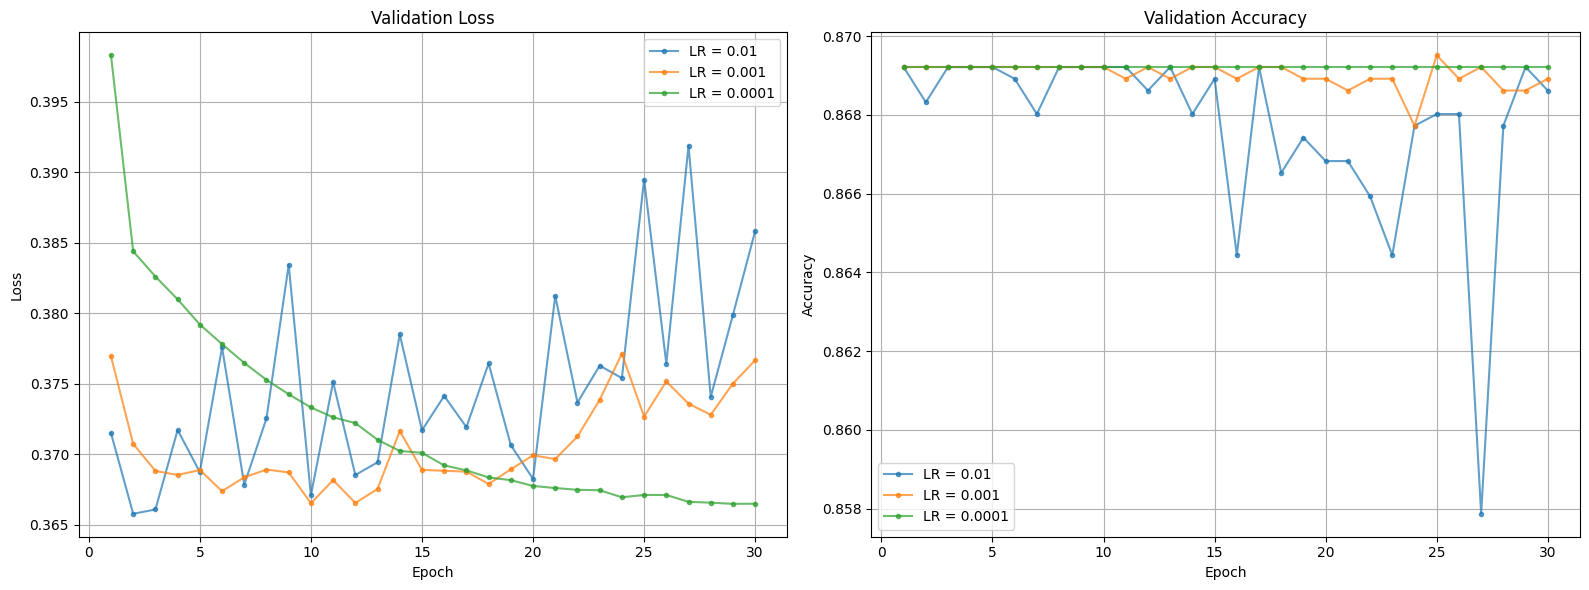

In [ ]:
hidden1_size = 32
hidden2_size = 16
num_epochs = 30
learning_rates = [0.01, 0.001, 0.0001]
results_dict = {}

for lr in learning_rates:
    print(f"\n\t Learning Rate = {lr}")

    model = DeepFFNN(input_size, hidden1_size, hidden2_size, output_size).to(device)

    history_lr = train_and_evaluate(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        num_epochs=num_epochs,
        learning_rate=lr,
        weight_decay=0.0,
        device=device,
        verbose=True,
        plot=False
    )

    results_dict[lr] = history_lr

epochs_range = range(1, num_epochs + 1)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
for lr, history in results_dict.items():
  plt.plot(epochs_range, history['val_losses'], label=f'LR = {lr}', marker='o', markersize=3, alpha=0.7)

plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for lr, history in results_dict.items():
    plt.plot(epochs_range, history['val_accs'], label=f'LR = {lr}', marker='o', markersize=3, alpha=0.7)

plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**ODPOWIEDŻ**

- Najstabilnejsze uczenie zapełnił learning rate 0.0001, moim zdaniem taka sytuacja jest przez zanadto wolne uczenie
- Najbardziej efektywnym uważam learning rate 0.001, ponieważ jest też już bardziej stabilny porównując do 0.01 + jednak szynciej się uczy of 0.0001

## 7. Dropout

1. Dodaj `Dropout` np. `0.0, 0.2, 0.5` , etc po każdej warstwie ukrytej.
2. Naucz model i porównaj z wersją bez regularizacji.
3. **Odpowiedz**: czy dropout zmniejszył overfitting ? Uzasadnij swoje obserwacje.

In [ ]:
class FFNN_Dropout(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size, dropout_p):
        super(FFNN_Dropout, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.act2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2_size, output_size)

        self.dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.act2(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

hidden1_size = 32
hidden2_size = 16
num_epochs = 30
lr = 0.001
dropout_ps = [0.0, 0.2, 0.5]
results = {}

for p in dropout_ps:
    print(f"\n\t Dropout = {p}")

    model = FFNN_Dropout(input_size, hidden1_size, hidden2_size, output_size, dropout_p=p).to(device)

    history_drop = train_and_evaluate(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        num_epochs=num_epochs,
        learning_rate=lr,
        device=device,
        verbose=True,
        plot=False
    )

    results[p] = history_drop


	 Dropout = 0.0
Epoch 1/30 | Train Loss: 0.3935, Train Acc: 0.8688 | Val Loss: 0.3787, Val Acc: 0.8692
Epoch 2/30 | Train Loss: 0.3757, Train Acc: 0.8692 | Val Loss: 0.3694, Val Acc: 0.8692
Epoch 3/30 | Train Loss: 0.3709, Train Acc: 0.8692 | Val Loss: 0.3719, Val Acc: 0.8692
Epoch 4/30 | Train Loss: 0.3667, Train Acc: 0.8692 | Val Loss: 0.3679, Val Acc: 0.8692
Epoch 5/30 | Train Loss: 0.3664, Train Acc: 0.8693 | Val Loss: 0.3675, Val Acc: 0.8692
Epoch 6/30 | Train Loss: 0.3662, Train Acc: 0.8693 | Val Loss: 0.3746, Val Acc: 0.8692
Epoch 7/30 | Train Loss: 0.3645, Train Acc: 0.8697 | Val Loss: 0.3666, Val Acc: 0.8692
Epoch 8/30 | Train Loss: 0.3621, Train Acc: 0.8698 | Val Loss: 0.3681, Val Acc: 0.8692
Epoch 9/30 | Train Loss: 0.3614, Train Acc: 0.8700 | Val Loss: 0.3666, Val Acc: 0.8686
Epoch 10/30 | Train Loss: 0.3596, Train Acc: 0.8698 | Val Loss: 0.3677, Val Acc: 0.8683
Epoch 11/30 | Train Loss: 0.3598, Train Acc: 0.8698 | Val Loss: 0.3658, Val Acc: 0.8689
Epoch 12/30 | Train Loss

3


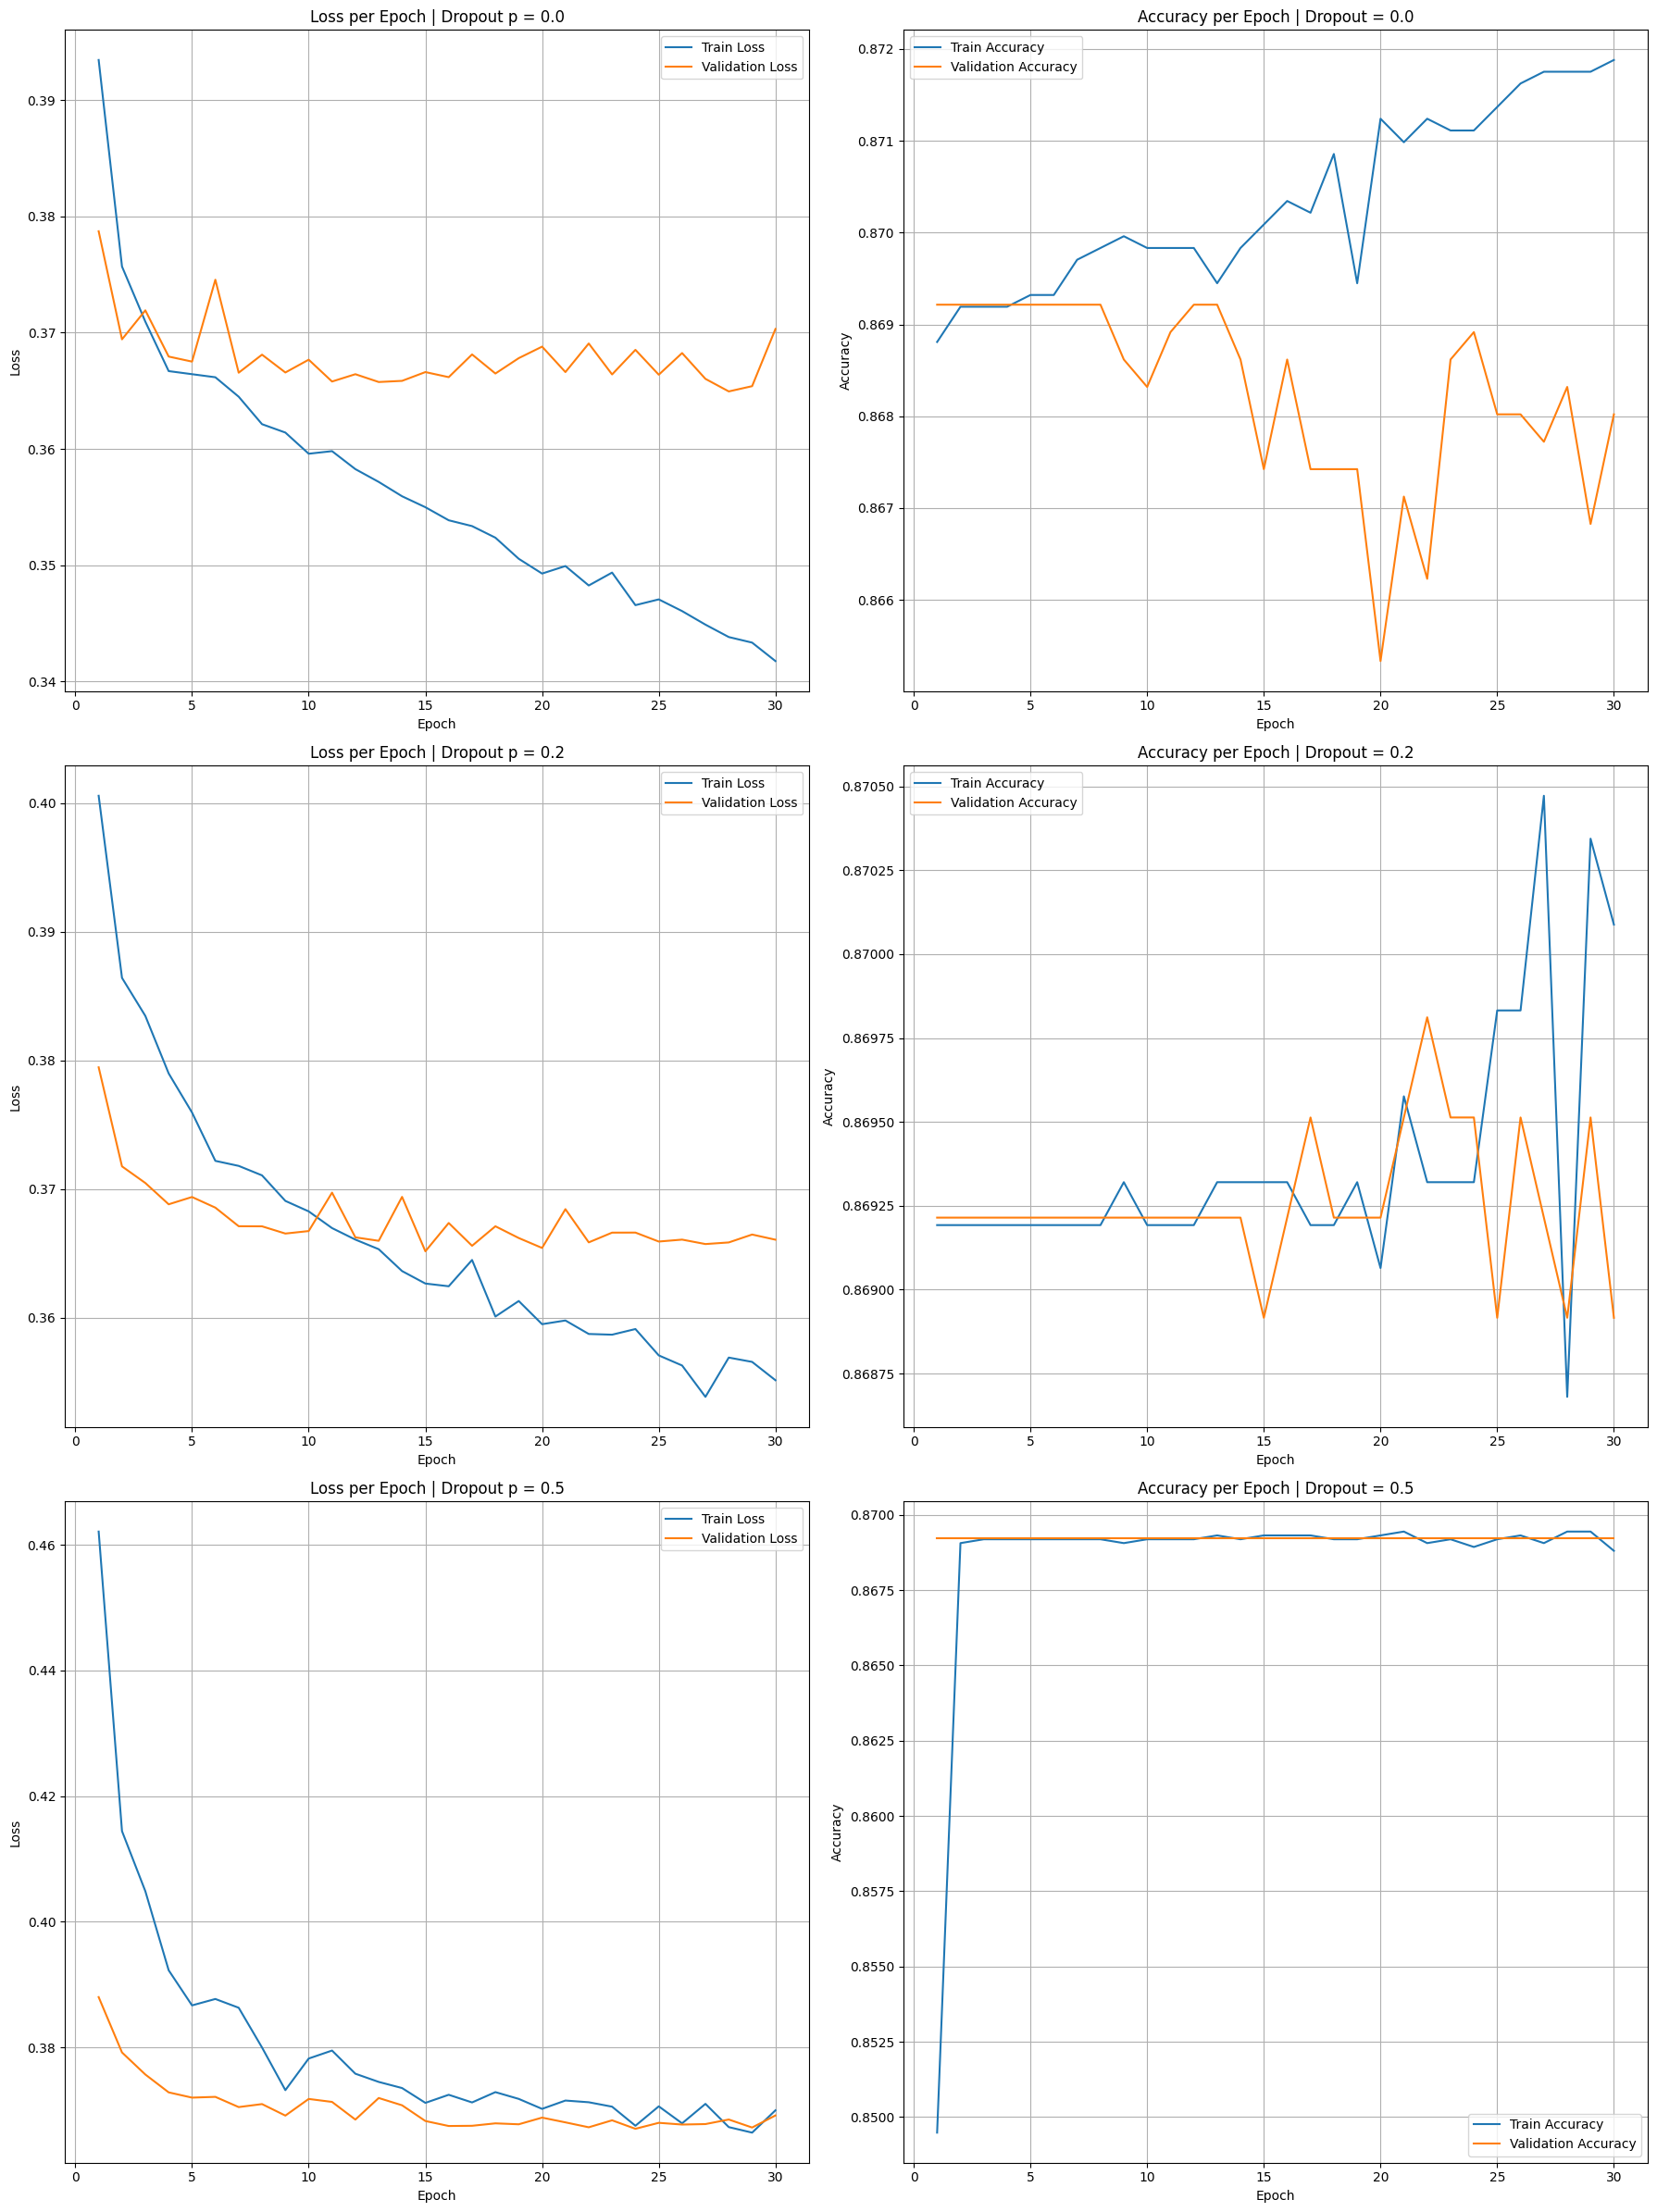

In [ ]:
epochs_range = range(1, num_epochs + 1)
num_plots = len(results)
print(num_plots)

plt.figure(figsize=(18, 8 * num_plots))

plot_index = 1
for p, history in results.items():
  plt.subplot(num_plots, 2, plot_index)
  plt.plot(epochs_range, history['train_losses'], label='Train Loss')
  plt.plot(epochs_range, history['val_losses'], label='Validation Loss')
  plt.title(f'Loss per Epoch | Dropout p = {p}')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  plt.subplot(num_plots, 2, plot_index + 1)
  plt.plot(epochs_range, history['train_accs'], label='Train Accuracy')
  plt.plot(epochs_range, history['val_accs'], label='Validation Accuracy')
  plt.title(f'Accuracy per Epoch | Dropout = {p}')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)

  plot_index += 2

plt.tight_layout()
plt.show()

**ODPOWIEDŻ**
- Z wykresów dobrze widać że już nawet na dropout 0.2 overfitting zmniejszył się
- Tak się dzieję przez to że dropout wyłącza randomowo neurony i to utrudnia modelowi uczenia się na danych treningowych